In [1]:
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd

# ------------------- 1D Wasserstein-1 loss -------------------
def wasserstein_loss_1d(x, y):
    """1D Wasserstein-1 distance as a loss function.
    In 1D, the W1 distance between two empirical distributions
    is the L1 distance between sorted samples."""
    x_sorted = torch.sort(x.squeeze())[0]
    y_sorted = torch.sort(y.squeeze())[0]
    return torch.mean(torch.abs(x_sorted - y_sorted))

# ------------------- Data loading (simulated pandas DataFrame) -------------------
# Replace this with your actual data loading, e.g. pd.read_csv('file.csv')
# For demonstration, create a DataFrame with a column 'value' containing NaNs

df = pd.read_csv("../data/processed/fwhm_linewidths.csv")


In [2]:
df = df[(df["transmission"] == 60) & (df["power_nW"]==3)]["fwhm"].dropna().reset_index(drop=True).copy()

In [3]:

# Convert to PyTorch tensor (float32)
exp_data = torch.tensor(df, dtype=torch.float32)*100

In [4]:
df

0       0.045822
1       0.025012
2       0.024199
3       0.027339
4       0.036384
          ...   
2621    0.022603
2622    0.018261
2623    0.021339
2624    0.033335
2625    0.036545
Name: fwhm, Length: 2626, dtype: float64

In [11]:
from tqdm import tqdm

# ------------------- Simulated data: start from a uniform distribution -------------------
# Use the same number of points as the cleaned experimental data
torch.manual_seed(42)
sim_data = torch.rand(exp_data.size()[0]) * 2 - 1    # uniform [-1, 1]
sim_data_initial = sim_data.clone()         # save for initial KDE

sim_data.requires_grad = True

# ------------------- KDE before optimisation -------------------
x_grid = np.linspace(-5, 7, 500)
exp_np = exp_data.numpy()
sim_init_np = sim_data_initial.detach().numpy()

kde_exp = gaussian_kde(exp_np)
kde_sim_init = gaussian_kde(sim_init_np)

# ------------------- Optimisation -------------------
optimizer = torch.optim.Adam([sim_data], lr=0.2)



  0%|          | 0/50 [00:00<?, ?it/s]

Step   1 | Loss = 3.094127


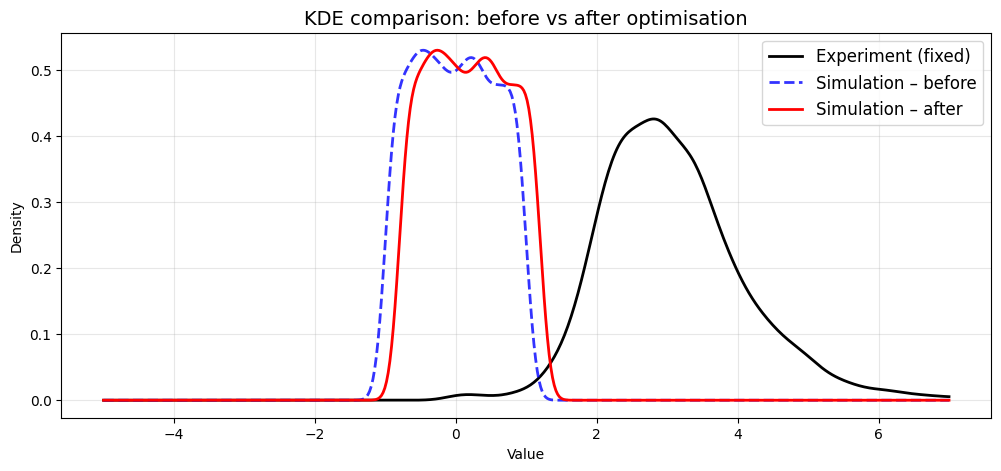

  2%|▏         | 1/50 [00:00<00:15,  3.14it/s]

Step  10 | Loss = 1.299879


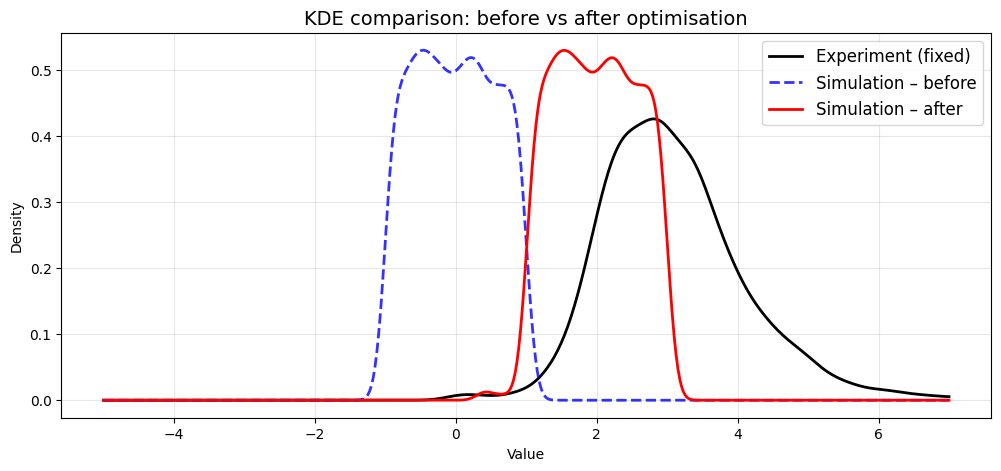

 20%|██        | 10/50 [00:00<00:01, 20.19it/s]

Step  20 | Loss = 0.438740


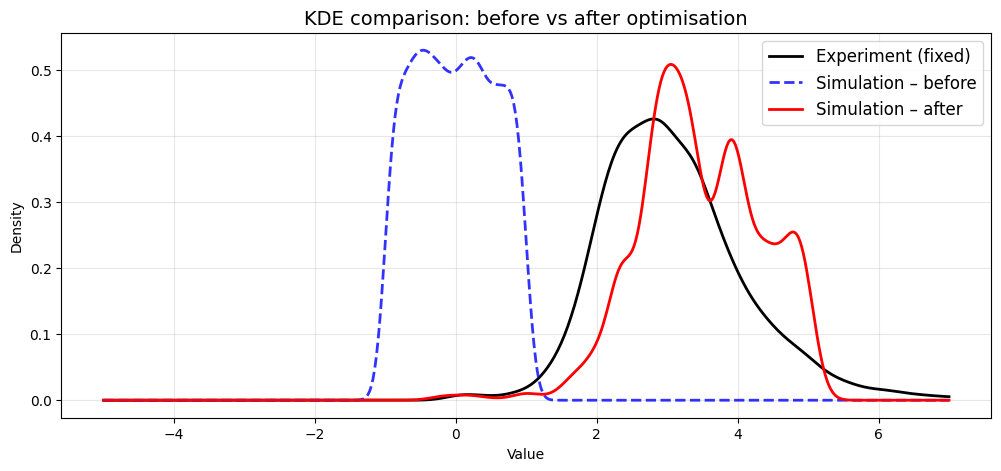

 40%|████      | 20/50 [00:00<00:01, 26.90it/s]

Step  30 | Loss = 0.154868


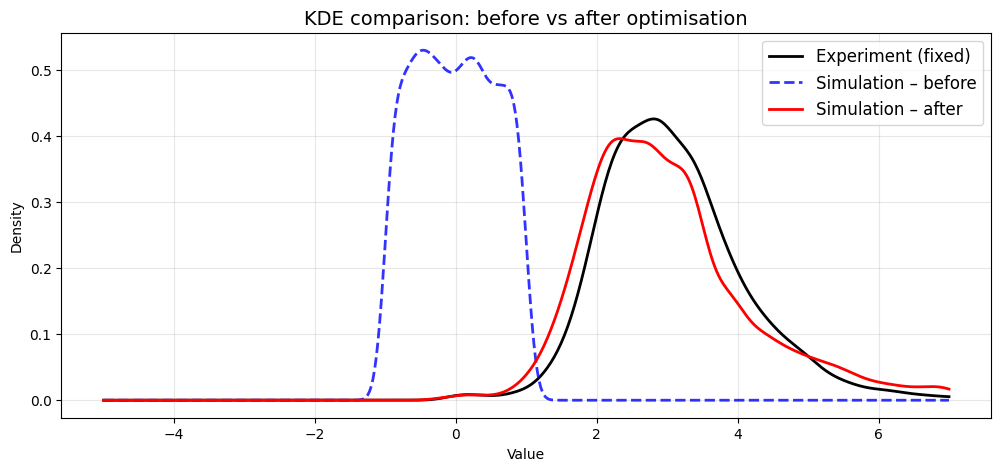

 60%|██████    | 30/50 [00:01<00:00, 29.43it/s]

Step  40 | Loss = 0.102627


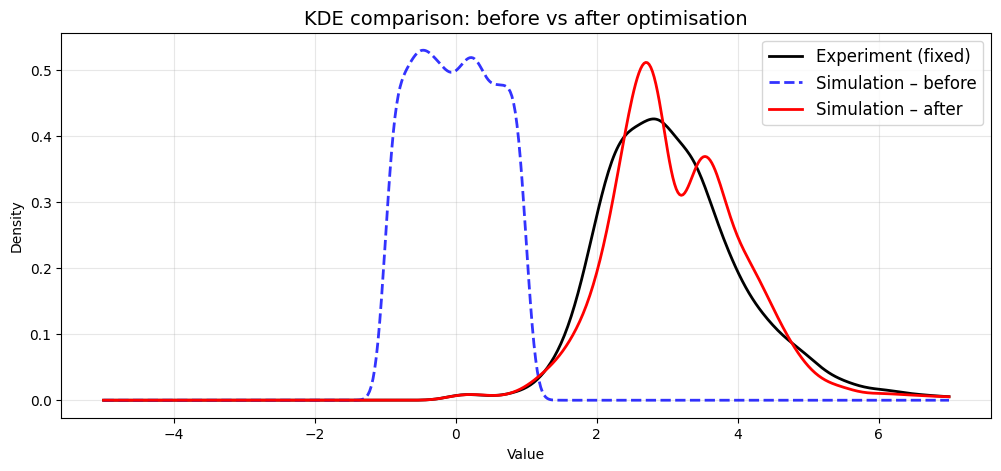

 80%|████████  | 40/50 [00:01<00:00, 30.20it/s]

Step  50 | Loss = 0.036673


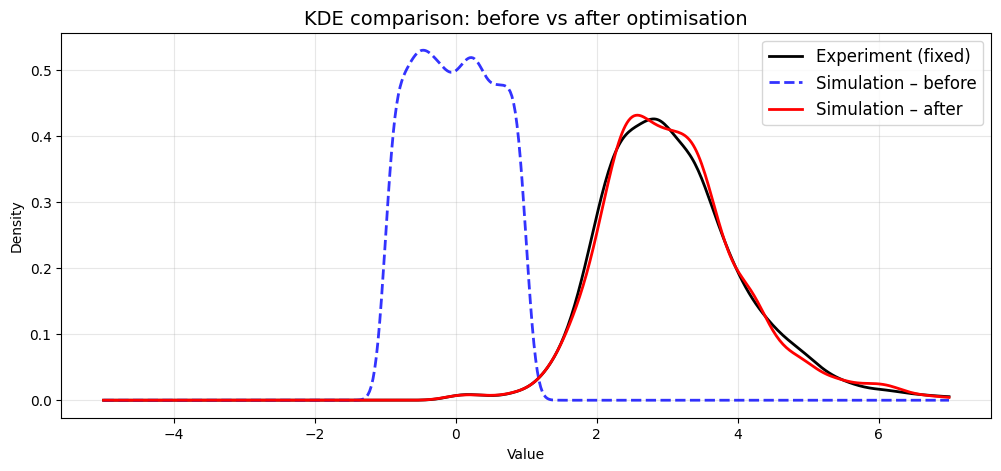

100%|██████████| 50/50 [00:01<00:00, 28.12it/s]


In [12]:

num_steps = 50
for step in tqdm(range(1, num_steps + 1)):
    optimizer.zero_grad()
    loss = wasserstein_loss_1d(exp_data, sim_data)
    loss.backward()
    optimizer.step()

    if (step % 10 == 0) or (step == 1):
        print(f"Step {step:3d} | Loss = {loss.item():.6f}")
        sim_final_np = sim_data.detach().numpy()
        kde_sim_final = gaussian_kde(sim_final_np)

        # ------------------- Visualisation -------------------
        plt.figure(figsize=(12, 5))

        # Plot experiment KDE
        plt.plot(x_grid, kde_exp(x_grid), 'k-', linewidth=2, label='Experiment (fixed)')

        # Plot initial simulation KDE
        plt.plot(x_grid, kde_sim_init(x_grid), 'b--', linewidth=2, alpha=0.8, label='Simulation – before')

        # Plot final simulation KDE
        plt.plot(x_grid, kde_sim_final(x_grid), 'r-', linewidth=2, label='Simulation – after')

        plt.legend(fontsize=12)
        plt.title('KDE comparison: before vs after optimisation', fontsize=14)
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.grid(alpha=0.3)
        plt.show()


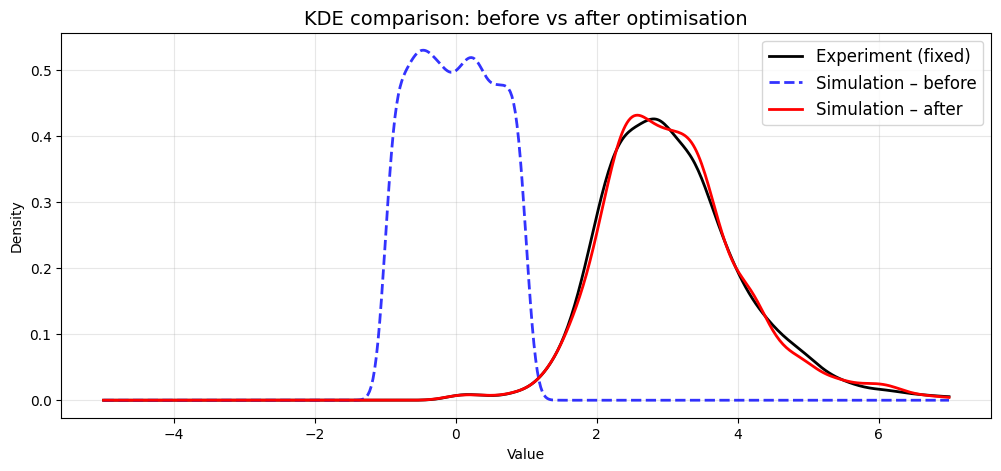

In [7]:

# ------------------- KDE after optimisation -------------------
sim_final_np = sim_data.detach().numpy()
kde_sim_final = gaussian_kde(sim_final_np)

# ------------------- Visualisation -------------------
plt.figure(figsize=(12, 5))

# Plot experiment KDE
plt.plot(x_grid, kde_exp(x_grid), 'k-', linewidth=2, label='Experiment (fixed)')

# Plot initial simulation KDE
plt.plot(x_grid, kde_sim_init(x_grid), 'b--', linewidth=2, alpha=0.8, label='Simulation – before')

# Plot final simulation KDE
plt.plot(x_grid, kde_sim_final(x_grid), 'r-', linewidth=2, label='Simulation – after')

plt.legend(fontsize=12)
plt.title('KDE comparison: before vs after optimisation', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.show()

## 1D Wasserstein-1 Loss (Parameter-Free)

Unlike MMD², the 1D Wasserstein distance requires no kernel bandwidth tuning.
It directly measures the L1 distance between the sorted samples of two distributions:

$$W_1(P, Q) = \frac{1}{N} \sum_{i=1}^N |P_{(i)} - Q_{(i)}|$$

where $P_{(i)}$ and $Q_{(i)}$ are the sorted samples.
This gives a natural, parameter-free way to match distributions in 1D.

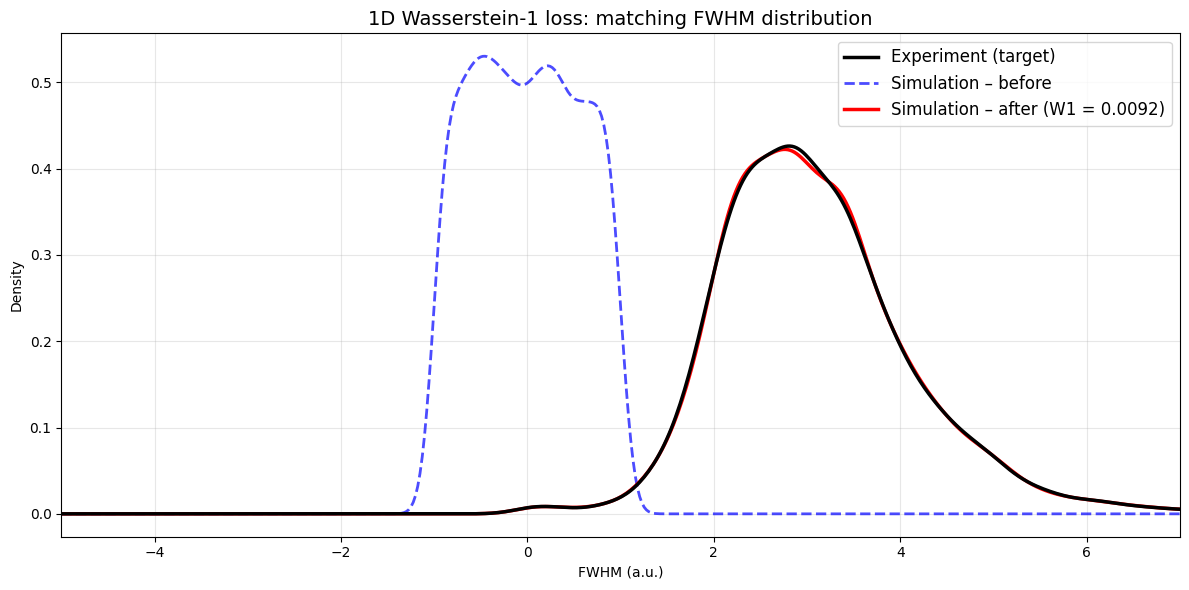

Final W1 loss = 0.009187


In [10]:
# ------------------- 1D Wasserstein optimisation (no parameter tuning) -------------------
# W1 is parameter-free, so a single run suffices
torch.manual_seed(42)
sim_w1 = torch.rand(len(exp_data)) * 2 - 1
sim_w1.requires_grad = True

optimizer = torch.optim.Adam([sim_w1], lr=0.2)
n_steps = 100

plt.figure(figsize=(12, 6))

# Plot target (experimental) distribution
plt.plot(x_grid, kde_exp(x_grid), 'k-', linewidth=2.5, label='Experiment (target)', zorder=10)

# Initial KDE
sim_init_np = sim_w1.detach().numpy()
kde_init = gaussian_kde(sim_init_np)
plt.plot(x_grid, kde_init(x_grid), 'b--', linewidth=2, alpha=0.7, label='Simulation – before')

# Optimize
for step in range(n_steps):
    optimizer.zero_grad()
    loss = wasserstein_loss_1d(exp_data, sim_w1)
    loss.backward()
    optimizer.step()

# Final KDE
sim_final_np = sim_w1.detach().numpy()
kde_final = gaussian_kde(sim_final_np)
plt.plot(x_grid, kde_final(x_grid), 'r-', linewidth=2.5, label=f'Simulation – after (W1 = {loss.item():.4f})')

plt.legend(fontsize=12)
plt.title('1D Wasserstein-1 loss: matching FWHM distribution', fontsize=14)
plt.xlabel('FWHM (a.u.)')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.xlim(-5, 7)
plt.tight_layout()
plt.show()

print(f'Final W1 loss = {loss.item():.6f}')